In [ ]:
# import library
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [2]:
# Define State
class State(TypedDict):
    height_m: float
    weight_kg: float
    bmi: float
    category:str

In [3]:
graph = StateGraph(State)

In [4]:
# Create nodes

def calculate_bmi(state: State) -> State:
    weight = state["weight_kg"]
    height = state["height_m"]

    bmi = weight / (height * height)

    state["bmi"] = round(bmi, 2)

    return state

def bmi_category(state: State) -> State:
    bmi = state["bmi"]

    if bmi < 18.5:
        state["category"] = "Underweight"
    elif bmi < 25:
        state["category"] = "Normal weight"
    elif bmi < 30:
        state["category"] = "Overweight"
    else:
        state["category"] = "Obese"

    return state



graph.add_node("calculate_bmi",calculate_bmi)
graph.add_node("bmi_category",bmi_category)

In [5]:
graph.add_edge(START, "calculate_bmi")
graph.add_edge("calculate_bmi","bmi_category")
graph.add_edge("bmi_category", END)

In [6]:
workflow = graph.compile()

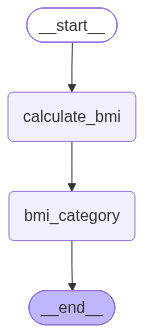

In [7]:
# Display graph
from IPython.display import Image, display

display(
    Image(
        workflow.get_graph().draw_mermaid_png()
    )
)

In [ ]:
# Invoke Graph

initial_state = {"weight_kg":80,"height_m":1.73}
response= workflow.invoke(initial_state)
print(response)

{'height_m': 1.73, 'weight_kg': 80, 'bmi': 26.73, 'category': 'Overweight'}
